In [1]:
!pip install -q langgraph langchain-google-genai langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.0 MB/s eta 0:00:00


In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import Image, display
import os

In [3]:
#configuring the Gemini APIs
os.environ["GOOGLE_API_KEY"]="API"

In [4]:
#initializing the gemini model
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [5]:
#defining the state schema
class TelecomState(TypedDict):

  #input
  complaint:str

  #intermediate output
  severity_analysis:str
  root_cause:str
  recommendation:str

  #final output
  final_summary:str

In [7]:
#Creating the first intermediate node
def analyze_severity(state:TelecomState):

  prompt=f"""
  You are a Telecom Incident Severity Analyzer.

  Analyze the following complaint and determine:
  - Severity level - Critical/High/Medium/Low
  - Business impact
  - Estimated urgency
  Complaint:
  {state['complaint']}
"""
  response=llm.invoke(prompt)

  return {"severity_analysis":response.content}

In [8]:
#Creating the second intermediate node
def identify_root_cause(state:TelecomState):

  prompt=f"""
  You are a Telecom Network Engineer. Predict the most likely root cause for this issue.

  Possible Causes:
  - Tower Congestion
  - Fiber Cut
  - Configuration issue
  - Power Outage
  - Maintenance issue
  Complaint:
  {state['complaint']}
  """

  response=llm.invoke(prompt)

  return{
      "root_cause":response.content
  }

In [9]:
#Creating the third intermediate node
def recommendation_action(state:TelecomState):

  prompt=f"""
  You are a Telecom Operations Specialist.

  Recommend the next operational actions based on:
  Complaint:
  {state['complaint']}
  """

  response=llm.invoke(prompt)

  return {
      "recommendation":response.content
  }

In [10]:
#Creating the final intermediate node
def generate_summary(state:TelecomState):

  prompt=f"""
  Create a Final Telecom Incident Report.and

  Complaint:
  {state['complaint']}

  Severity Analysis:
  {state['severity_analysis']}

  Root Cause:
  {state['root_cause']}

  Recommendation
  {state['recommendation']}

  Generate:
  - Executive Summary
  - Priority Level
  - Suggested SLA
  - Escalation Notes
  """

  response=llm.invoke(prompt)
  return{
      "final_summary":response.content
  }

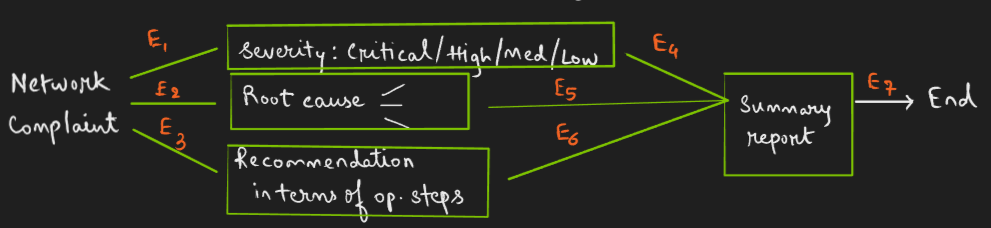

In [11]:
#Building the LangGraph Workflow
graph=StateGraph(TelecomState)

#add nodes
graph.add_node("severity",analyze_severity)
graph.add_node("rootcause",identify_root_cause)
graph.add_node("recommend",recommendation_action)
graph.add_node("summary",generate_summary)

#add edges
graph.add_edge(START,"severity")
graph.add_edge(START,"rootcause")
graph.add_edge(START,"recommend")
graph.add_edge("severity","summary")
graph.add_edge("rootcause","summary")
graph.add_edge("recommend","summary")
graph.add_edge("summary",END)

workflow=graph.compile()

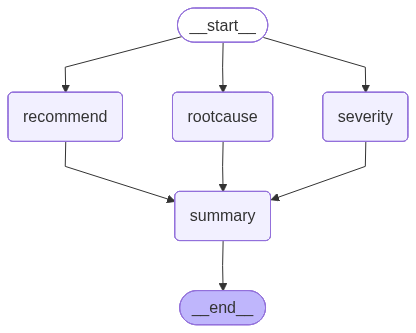

In [12]:
workflow

In [13]:
initial_state={
    "complaint":"""
    Customer in North-Delhi region is experiencing repeated call drops and poor 5G connectivity.
    Around 300+ complaints have been registered since last 2 hours."""
}

In [14]:
output=workflow.invoke(initial_state)

In [15]:
print(output["root_cause"])

The most likely root cause for this issue is a **Fiber Cut**.

Here's why:

1.  **Widespread Impact:** 300+ complaints in a specific region (North-Delhi) within 2 hours indicates a significant, localized outage or severe degradation affecting multiple users and potentially multiple towers.
2.  **Symptoms:** "Repeated call drops and poor 5G connectivity" points to a problem where the towers themselves might be powered on and broadcasting, but their ability to connect to the core network and carry data/voice traffic is severely impaired. 5G, in particular, is very sensitive to backhaul capacity and latency.
3.  **Fiber Cut Explanation:** A fiber cut in a key segment serving North-Delhi would sever the backhaul connection for multiple towers in that area. While the towers might still be powered, they wouldn't be able to send/receive user traffic effectively, leading to:
    *   **Call Drops:** Calls can't be set up or maintained because the connection to the core is broken or severely deg

In [17]:
print(output["final_summary"])

## Final Telecom Incident Report

**Incident ID:** INC-20231027-ND-001
**Date & Time of Report:** October 27, 2023, 16:30 IST
**Reporting Team:** Network Operations Center (NOC)

---

### Executive Summary

On October 27, 2023, starting approximately 13:00 IST, a Critical service incident was reported in the North-Delhi region, significantly impacting approximately 300+ customers within a two-hour period. Customers experienced repeated call drops and severe degradation of 5G connectivity. Investigation confirmed the root cause as a physical fiber optic cable cut in a critical backhaul segment serving multiple cell sites in the affected area. Immediate and coordinated response from NOC, Transmission, and Field Operations teams led to the identification and repair of the fiber cut, restoring full service functionality to the region by 14:45 IST. This report details the incident, its impact, resolution, and preventative measures.

---

### Incident Details

*   **Region Affected:** North-

#Task - Loan Application Review Assistant

Banks receive thousands of loan applications and the operations team must:
- Review repayment capability - financial health
- Assess lending risk - risk assessment
- Check documentation quality review
- Generate approval recommnedation

Our objective is to build a Parallel Agentic Workflow which can act as a Preliminary Loan Assessment Assistant
